# 参照表現ペアリング結果の集計
## Summary of Reference Expression Pairing Results

In [8]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("data/")

# 訳書ラベル
FILES = {
    "石川（1913）": "1894-1913-mentions.csv",
    "三上（1921）": "1894-1921-mentions.csv",
    "矢口（1927）": "1894-1927-mentions.csv",
    "生田（1928）": "1894-1928-mentions.csv",
    "原田（1939）": "1894-1939-mentions.csv",
    "岩崎（1958）": "1894-1958-mentions.csv",
    "野上（1961）": "1894-1961-mentions.csv",
    "脇（2010）": "1894-2010-mentions.csv",
}

# @pos の値
LABEL = {
    "DET": "限定詞",
    "NOUN": "名詞句",
    "NULL": "ゼロ",
    "MISSING": "未対応",
    "PRON": "代名詞",
    "PROPN": "固有名詞",
    "PRON-REFLEX": "再帰代名詞",
}

# 表の列順
TARGET_ORDER = ["限定詞", "名詞句", "ゼロ", "未対応", "代名詞", "固有名詞"]


def load(path):
    """"NULL" is a pandas missing-value sentinel by default and would be read
    back as NaN, emptying every zero-subject row."""
    df = pd.read_csv(path, encoding="utf-8-sig",
                     keep_default_na=False, na_values=[])
    if not (df.source_pos == "NULL").any():
        raise ValueError(f"{path}: no NULL rows — NA inference still active?")
    return df


data = {name: load(DATA_DIR / f) for name, f in FILES.items()}

for name, df in data.items():
    print(f"{name}  {len(df):>6,} rows")
print(f"{'合計':<12} {sum(len(d) for d in data.values()):>6,} rows")

石川（1913）   3,416 rows
三上（1921）   3,453 rows
矢口（1927）   2,822 rows
生田（1928）   3,487 rows
原田（1939）   3,385 rows
岩崎（1958）   3,558 rows
野上（1961）   3,593 rows
脇（2010）   3,518 rows
合計           27,232 rows


## 条件付き確率の計算

### Calculation of Conditional Probabilities

`source_pos` を分母とし，`target_pos` の分布を求める。

Calculate the distribution of `target_pos` using `source_pos` as the denominator.

In [9]:
def prob_table(source_pos, decimals=1):
    """P(target_pos | source_pos, translation) as percentages, one row per translation."""
    rows = {}
    for name, df in data.items():
        sub = df[df.source_pos == source_pos]
        counts = (sub.target_pos.map(LABEL)
                     .value_counts()
                     .reindex(TARGET_ORDER, fill_value=0))
        rows[name] = counts / len(sub) * 100 if len(sub) else counts * 0.0
    out = pd.DataFrame(rows).T[TARGET_ORDER].round(decimals)
    out.index.name = "訳書"
    return out

## 対応候補数

### Number of Paired and Unpaired Candidates

In [17]:
tab2 = pd.DataFrame(
    {"対応候補数": {name: len(df) for name, df in data.items()}}
)
tab2.index.name = "訳書"
tab2.style.format("{:,}")

,対応候補数
訳書,
石川（1913）,"3,416"
三上（1921）,"3,453"
矢口（1927）,"2,822"
生田（1928）,"3,487"
原田（1939）,"3,385"
岩崎（1958）,"3,558"
野上（1961）,"3,593"
脇（2010）,"3,518"


## 限定詞の訳に関する条件付き確率

### Conditional probabilities for how determiners were translated

In [18]:
tab_det = prob_table("DET")
display(tab_det.style.format("{:.1f}%"))

target_pos,限定詞,名詞句,ゼロ,未対応,代名詞,固有名詞
訳書,,,,,,
石川（1913）,2.2%,11.2%,0.0%,53.4%,33.2%,0.0%
三上（1921）,2.3%,4.9%,0.0%,29.4%,63.4%,0.0%
矢口（1927）,4.3%,4.8%,0.0%,37.0%,52.9%,1.0%
生田（1928）,3.7%,4.9%,0.0%,36.3%,54.7%,0.4%
原田（1939）,2.6%,4.8%,0.0%,19.2%,73.4%,0.0%
岩崎（1958）,3.0%,6.3%,0.0%,32.8%,55.7%,2.2%
野上（1961）,1.8%,5.9%,0.0%,23.5%,68.0%,0.7%
脇（2010）,2.6%,8.8%,0.0%,31.6%,56.6%,0.4%


## 非再帰代名詞の訳に関する条件付き確率
### Conditional probabilities for how non-reflexive pronouns were translated

In [19]:
tab_pron = prob_table("PRON")
display(tab_pron.style.format("{:.1f}%"))

target_pos,限定詞,名詞句,ゼロ,未対応,代名詞,固有名詞
訳書,,,,,,
石川（1913）,1.0%,12.8%,12.8%,42.5%,29.4%,1.5%
三上（1921）,0.3%,4.6%,3.6%,25.4%,64.9%,1.3%
矢口（1927）,0.4%,6.2%,7.5%,35.1%,48.0%,2.9%
生田（1928）,0.3%,4.9%,6.2%,29.3%,57.1%,2.2%
原田（1939）,0.4%,3.9%,3.6%,20.0%,72.2%,0.0%
岩崎（1958）,0.6%,5.4%,4.5%,26.5%,61.5%,1.5%
野上（1961）,0.5%,6.2%,2.9%,21.5%,67.0%,1.8%
脇（2010）,0.6%,7.2%,5.5%,25.7%,58.3%,2.7%


## ゼロ主語の訳に関する条件付き確率

### Conditional probabilities for how zero subjects were translated 

In [20]:
tab_zero = prob_table("NULL")
display(tab_zero.style.format("{:.1f}%"))

target_pos,限定詞,名詞句,ゼロ,未対応,代名詞,固有名詞
訳書,,,,,,
石川（1913）,0.0%,2.0%,59.9%,35.2%,2.7%,0.2%
三上（1921）,0.0%,1.9%,50.4%,28.9%,18.8%,0.1%
矢口（1927）,0.0%,1.6%,55.7%,35.0%,7.4%,0.3%
生田（1928）,0.0%,1.7%,57.2%,29.7%,11.3%,0.1%
原田（1939）,0.0%,1.1%,63.9%,21.8%,13.2%,0.0%
岩崎（1958）,0.0%,2.7%,61.8%,24.7%,10.8%,0.0%
野上（1961）,0.0%,2.3%,58.9%,24.1%,14.4%,0.4%
脇（2010）,0.0%,2.8%,62.5%,25.5%,8.8%,0.4%


## 参照戦略の類似性を示すヒートマップと階層的クラスター分析

## Clustering analysis and heatmap illustrating similarities of coreference strategy

変数は，イタリア語側の 5 品詞それぞれについての条件付き確率である。再帰代名詞は対応付けが不安定であるため除外し，構造上つねに 0 となる「限定詞 → ゼロ」と
「ゼロ → 限定詞」も除外する。

The variables represent the conditional probabilities for each of the five parts of speech in Italian. Since the mapping of reflexive pronouns is unstable, they are excluded, as are “determiner → zero” and
“zero → determiner,” which are structurally always 0.

In [21]:
SOURCE_ORDER = ["DET", "NOUN", "NULL", "PRON", "PROPN"]
DROP = ["限定詞 -> ゼロ", "ゼロ -> 限定詞"]

wide = pd.concat(
    {LABEL[s]: prob_table(s, decimals=6) / 100 for s in SOURCE_ORDER},
    axis=1,
)
wide.columns = [f"{src} -> {tgt}" for src, tgt in wide.columns]
values = wide.drop(columns=DROP)

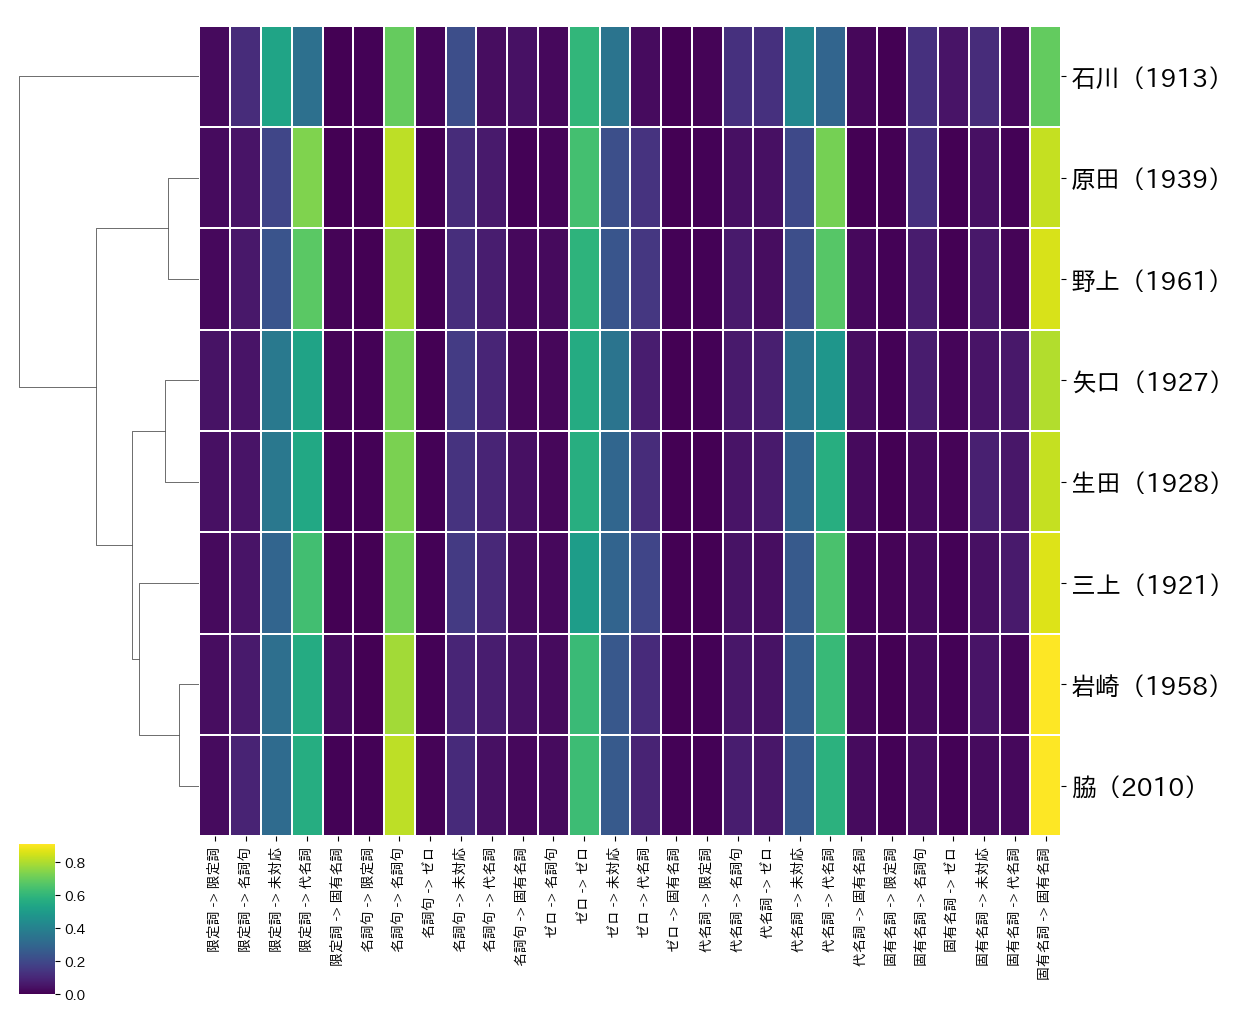

In [22]:
from scipy.cluster.hierarchy import linkage

import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

linkage_matrix = linkage(values, method="ward", metric="euclidean")

g = sns.clustermap(
    values,
    row_linkage=linkage_matrix,
    col_cluster=False,
    cmap="viridis",
    figsize=(12, 10),
    linewidths=0.3,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.18, 0.02),
    cbar_pos=(0.02, 0, 0.03, 0.15),
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=10, labelrotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=18)

g.savefig("fig2-clustering.png", dpi=300, bbox_inches="tight")
plt.show()

### 結合順序と結合距離

### Order of Clusters and Clustering Distances

樹形図の枝の高さを数値で確認する。

Check the heights of the branches in the dendrogram numerically.

In [23]:
labels = list(values.index)
clusters = {i: [lab] for i, lab in enumerate(labels)}

for k, (a, b, dist, size) in enumerate(linkage_matrix):
    a, b = int(a), int(b)
    merged = clusters[a] + clusters[b]
    clusters[len(labels) + k] = merged
    print(f"{dist:6.3f}  ({len(merged)})  "
          f"{{{', '.join(clusters[a])}}} + {{{', '.join(clusters[b])}}}")

 0.086  (2)  {岩崎（1958）} + {脇（2010）}
 0.135  (2)  {原田（1939）} + {野上（1961）}
 0.149  (2)  {矢口（1927）} + {生田（1928）}
 0.260  (3)  {三上（1921）} + {岩崎（1958）, 脇（2010）}
 0.290  (5)  {矢口（1927）, 生田（1928）} + {三上（1921）, 岩崎（1958）, 脇（2010）}
 0.442  (7)  {原田（1939）, 野上（1961）} + {矢口（1927）, 生田（1928）, 三上（1921）, 岩崎（1958）, 脇（2010）}
 0.774  (8)  {石川（1913）} + {原田（1939）, 野上（1961）, 矢口（1927）, 生田（1928）, 三上（1921）, 岩崎（1958）, 脇（2010）}
